# Electrostatic interaction energy correlation with P-RMSD values during MD simulations

## DNMT3A

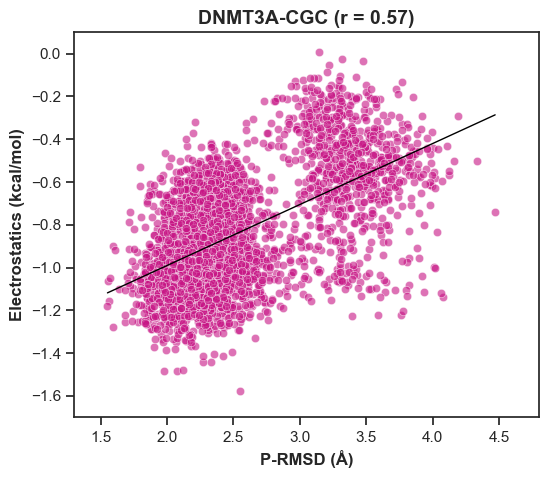

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set dataset name
dataset_name = "3a-cgc"

# Define file prefixes dynamically
energy_prefix = f"DNMT3A_inputs/FoldX/output_{dataset_name}"
rmsd_prefix = f"DNMT3A_inputs/ProFit/{dataset_name}"

# Initialize empty list to store filtered data
all_data = []
datasets = [] 

for i in range(1, 5):
    energy_file = f"{energy_prefix}-{i}"
    rmsd_file = f"{rmsd_prefix}-{i}-sorted"

    # Load FoldX data
    b = pd.read_csv(energy_file, sep=" ", header=None)
    b.columns = ["Pdb", "Group1", "Group2", "IntraclashesGroup1", "IntraclashesGroup2", "Interaction Energy"
                 , "Backbone Hbond", "Sidechain Hbond", "Van der Waals", "Electrostatics", "Solvation Polar", "Solvation Hydrophobic",
                "Van der Waals clashes", "entropy sidechain", "entropy mainchain", "sloop_entropy", "mloop_entropy",
                "cis_bond", "torsional clash", "backbone clash", "helix dipole", "water bridge", "disulfide",
                 "electrostatic kon", "partial covalent bonds", "energy Ionisation", "Entropy Complex", "Number of Residues", "Interface Residues",
                "Interface Residues Clashing", "Interface Residues VdW Clashing", "Interface Residues BB Clashing"]

    # Extract and convert time
    b['Pdb_time'] = b['Pdb'].astype(str).str.extract(r'_(\d+)\D*\.pdb').astype(float)
    b['Time'] = b['Pdb_time'] / 2  # Convert to nanoseconds
    b = b.sort_values(by=['Time'])

    # Discard frames corresponding to equilibration
    b = b[b['Time'] > 100]

    # Load ProFit data
    a = pd.read_csv(rmsd_file, sep="\t", header=None)
    a.columns = ["frame", "rmsd"]
    dataset_id = f"{dataset_name}-{i}" 
    a['Type'] = dataset_id
    datasets.append(dataset_id)  

    # Extract and convert time
    a['Pdb_time'] = a['frame'].astype(str).str.extract(r'_(\d+)\D*\.pdb').astype(float)
    a['Time'] = a['Pdb_time'] / 2  # Convert to nanoseconds
    a = a.sort_values(by=['Time'])

    # Discard frames corresponding to equilibration
    a = a[a['Time'] > 100]

    # Merge RMSD and energy data on 'Time'
    merged_df = pd.merge(a, b, on="Time", how="inner")
    merged_df["Dataset"] = dataset_id  # Tag dataset source
    all_data.append(merged_df)  # Store the merged dataset

final_df = pd.concat(all_data, ignore_index=True)
correlation = final_df[["rmsd", "Electrostatics"]].corr().loc["rmsd", "Electrostatics"]

sns.set(style="ticks")

plt.figure(figsize=(6, 5))

for dataset in datasets:
    subset = final_df[final_df["Dataset"] == dataset]
    sns.scatterplot(
        data=subset, x="rmsd", y="Electrostatics", alpha=0.6,
        color="#C71585"
    )

sns.regplot(
    data=final_df, x="rmsd", y="Electrostatics", scatter=False,
    line_kws={"color": "black", "linewidth": 1}, ci=None
)

plt.ylim(-1.7, 0.1) 
plt.xlim(1.3, 4.8)  

formatted_dataset_name = dataset_name.upper()
plt.title(f"DNMT{formatted_dataset_name} (r = {correlation:.2f})",
          fontsize=14, fontweight="bold")
plt.xlabel("P-RMSD (Å)", fontsize=12, fontweight="bold")
plt.ylabel("Electrostatics (kcal/mol)", fontsize=12, fontweight="bold")

output_filename = f"electrostatics_vs_rmsd_{dataset_name}.png"
plt.savefig(output_filename, dpi=600, bbox_inches="tight", format="png")
plt.show()

## DNMT3B

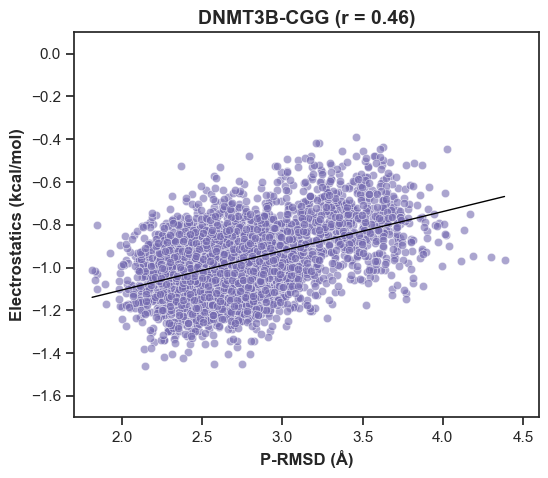

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set dataset name
dataset_name = "3b-cgg"

# Define file prefixes dynamically
energy_prefix = f"DNMT3B_inputs/FoldX/output_{dataset_name}"
rmsd_prefix = f"DNMT3B_inputs/ProFit/{dataset_name}"

# Initialize empty list to store filtered data
all_data = []
datasets = [] 

for i in range(1, 5):
    energy_file = f"{energy_prefix}-{i}"
    rmsd_file = f"{rmsd_prefix}-{i}-sorted"

    # Load FoldX data
    b = pd.read_csv(energy_file, sep=" ", header=None)
    b.columns = ["Pdb", "Group1", "Group2", "IntraclashesGroup1", "IntraclashesGroup2", "Interaction Energy"
                 , "Backbone Hbond", "Sidechain Hbond", "Van der Waals", "Electrostatics", "Solvation Polar", "Solvation Hydrophobic",
                "Van der Waals clashes", "entropy sidechain", "entropy mainchain", "sloop_entropy", "mloop_entropy",
                "cis_bond", "torsional clash", "backbone clash", "helix dipole", "water bridge", "disulfide",
                 "electrostatic kon", "partial covalent bonds", "energy Ionisation", "Entropy Complex", "Number of Residues", "Interface Residues",
                "Interface Residues Clashing", "Interface Residues VdW Clashing", "Interface Residues BB Clashing"]

    # Extract and convert time
    b['Pdb_time'] = b['Pdb'].astype(str).str.extract(r'_(\d+)\D*\.pdb').astype(float)
    b['Time'] = b['Pdb_time'] / 2  # Convert to nanoseconds
    b = b.sort_values(by=['Time'])

    # Discard frames corresponding to equilibration
    b = b[b['Time'] > 100]

    # Load ProFit data
    a = pd.read_csv(rmsd_file, sep="\t", header=None)
    a.columns = ["frame", "rmsd"]
    dataset_id = f"{dataset_name}-{i}" 
    a['Type'] = dataset_id
    datasets.append(dataset_id)  

    # Extract and convert time
    a['Pdb_time'] = a['frame'].astype(str).str.extract(r'_(\d+)\D*\.pdb').astype(float)
    a['Time'] = a['Pdb_time'] / 2  # Convert to nanoseconds
    a = a.sort_values(by=['Time'])

    # Discard frames corresponding to equilibration
    a = a[a['Time'] > 100]

    # Merge RMSD and energy data on 'Time'
    merged_df = pd.merge(a, b, on="Time", how="inner")
    merged_df["Dataset"] = dataset_id  # Tag dataset source
    all_data.append(merged_df)  # Store the merged dataset

final_df = pd.concat(all_data, ignore_index=True)
correlation = final_df[["rmsd", "Electrostatics"]].corr().loc["rmsd", "Electrostatics"]

sns.set(style="ticks")

plt.figure(figsize=(6, 5))

for dataset in datasets:
    subset = final_df[final_df["Dataset"] == dataset]
    sns.scatterplot(
        data=subset, x="rmsd", y="Electrostatics", alpha=0.6,
        color="#746AB0"
    )

sns.regplot(
    data=final_df, x="rmsd", y="Electrostatics", scatter=False,
    line_kws={"color": "black", "linewidth": 1}, ci=None
)

plt.ylim(-1.7, 0.1)
plt.xlim(1.7, 4.6)  

formatted_dataset_name = dataset_name.upper()
plt.title(f"DNMT{formatted_dataset_name} (r = {correlation:.2f})",
          fontsize=14, fontweight="bold")
plt.xlabel("P-RMSD (Å)", fontsize=12, fontweight="bold")
plt.ylabel("Electrostatics (kcal/mol)", fontsize=12, fontweight="bold")

output_filename = f"electrostatics_vs_rmsd_{dataset_name}.png"
plt.savefig(output_filename, dpi=600, bbox_inches="tight", format="png")
plt.show()